<a href="https://colab.research.google.com/github/sjkim25/Introduction-to-Artificial-Intelligence/blob/main/week11/Calligraphy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CNN**

In [24]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [25]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1)) # 이미지 높이, 이미지 너비, 채널 개수
test_images = test_images.reshape((10000, 28, 28, 1))

In [26]:
train_images, test_images = train_images / 255.0, test_images / 255.0

In [27]:
# 컨벌루션 신경망 생성
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# dense 레이어 추가
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
# 모델 출력
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # sparse_categorical_crossentropy -> 훈련 샘플의 출력을 원-핫 인코딩으로 만들지 않아도 됨
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.9539 - loss: 0.1470
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9852 - loss: 0.0464
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9893 - loss: 0.0329
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 29ms/step - accuracy: 0.9920 - loss: 0.0250
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9938 - loss: 0.0200


In [30]:
# 결과 예측
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [31]:
print("Confusion Matrix:")
print(confusion_matrix(test_labels, y_pred_classes))

print("\nClassification Report:")
print(classification_report(test_labels, y_pred_classes))

Confusion Matrix:
[[ 976    0    1    0    0    0    1    0    0    2]
 [   3 1127    0    1    0    3    1    0    0    0]
 [   0    0 1027    0    1    0    0    4    0    0]
 [   0    0    1 1007    0    2    0    0    0    0]
 [   0    0    0    0  973    0    0    0    3    6]
 [   1    0    0    3    0  882    1    1    2    2]
 [   4    2    2    1    1    3  944    0    1    0]
 [   0    4   12    1    1    1    0 1003    0    6]
 [   2    0    2    1    0    1    0    1  965    2]
 [   1    0    0    0    4    7    0    0    5  992]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.99      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       1.00      0.99      0.99     

In [32]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("테스트 정확도:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9896 - loss: 0.0314
테스트 정확도: 0.9896000027656555


**DNN**

In [33]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

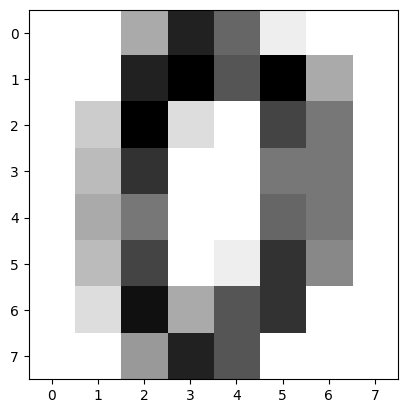

In [34]:
# 데이터 로딩
digits = datasets.load_digits()
plt.imshow(digits.images[0], cmap=plt.cm.gray_r, interpolation='nearest')

In [35]:
X = digits.data
y = digits.target

In [36]:
# 정규화 및 원-핫 인코딩
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = to_categorical(y, 10)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1437, 64), (360, 64), (1437, 10), (360, 10))

In [39]:
# 모델 생성
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(64,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3633 - loss: 1.9959 - val_accuracy: 0.6528 - val_loss: 1.4228
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8038 - loss: 0.9940 - val_accuracy: 0.8917 - val_loss: 0.6428
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9074 - loss: 0.4810 - val_accuracy: 0.9194 - val_loss: 0.3528
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9422 - loss: 0.2889 - val_accuracy: 0.9417 - val_loss: 0.2417
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9645 - loss: 0.1997 - val_accuracy: 0.9556 - val_loss: 0.1909


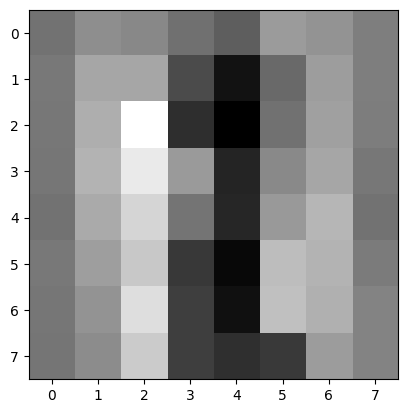

In [42]:
#이미지 출력
plt.imshow(X_test[10].reshape(8,8), cmap=plt.cm.gray_r, interpolation='nearest')

In [43]:
# 이미지 결과 예측
y_pred = model.predict(X_test[10].reshape(1, -1))
predicted_label = np.argmax(y_pred)

print("실제 정답:", np.argmax(y_test[10]))
print("DNN 예측 결과:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
실제 정답: 1
DNN 예측 결과: 1


In [44]:
# 전체 결과 예측
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [45]:
print("Confusion Matrix:")
print(confusion_matrix(y_test_classes, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes))

Confusion Matrix:
[[31  0  0  0  1  0  0  0  0  1]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  1 30  0  1  0  0  1  1]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 46  0  0  0  1]
 [ 1  0  0  0  0  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  1  1  0  0  1  0  0 27  0]
 [ 0  0  0  0  0  1  0  0  3 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        33
           1       0.97      1.00      0.98        28
           2       0.94      1.00      0.97        33
           3       1.00      0.88      0.94        34
           4       0.98      1.00      0.99        46
           5       0.94      0.98      0.96        47
           6       1.00      0.97      0.99        35
           7       1.00      0.97      0.99        34
           8       0.87      0.90      0.89        30
           9       0.90      0.90      0.90        40

    accuracy                   